# 1D Drone Altitude Estimation: Multi-Sensor Fusion with Kalman Filters

**Objective:** Estimate the true altitude of a hovering drone by fusing data from two flawed sensors.

In the real world, whether you are trying to stabilize a quadcopter or extract clean end-effector coordinates for an imitation learning policy, sensors lie. Any control algorithm that assumes perfect state observations will quickly fail when exposed to real hardware noise. 

This notebook demonstrates a foundational concept in state estimation: **Sensor Fusion via a 1D Kalman Filter**. 

We will simulate a drone attempting to hold a steady 10-meter altitude and track its state using two imperfect data streams:
1. **A Barometer:** Measures air pressure. It provides smooth, continuous data but suffers from slow, unpredictable drift.
2. **An Ultrasonic Sensor:** Bounces sound waves off the ground. It is generally accurate but prone to massive, random spikes or dropouts.

By utilizing the predictable physics of the drone (the *Predict* step) and mathematically weighting the confidence of each sensor (the *Update* step), the Kalman Filter acts as a highly intelligent weighted average. It filters out the barometer's drift and ignores the ultrasonic spikes, outputting a clean, reliable state estimate that is actually more accurate than either individual sensor.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(42)


## Part 2: Initializing the Filter Matrices

Before the filter can run, we must define the shape of our world. 

**The Dimensions Rule:**
* **Variables (n) = 2:** We are tracking Altitude and Vertical Velocity.
* **Sensors (m) = 2:** We have a Barometer and an Ultrasonic sensor.

Because of this, our matrices will primarily be 2x1 vectors or 2x2 grids.

* **State (x):** A 2x1 column tracking [Altitude, Velocity].
* **Covariance (P):** A 2x2 grid. Why 2x2? Because it must track the uncertainty of Altitude (top-left), the uncertainty of Velocity (bottom-right), AND how Altitude and Velocity affect each other (the cross-correlations in the top-right and bottom-left).
* **Physics (F):** A 2x2 matrix that multiplies against the 2x1 state to calculate the new state.
* **Measurement Map (H):** A 2x2 matrix. It has 2 rows (one for each sensor) and 2 columns (one for each state variable). It tells the computer which state variable each sensor is looking at.

In [6]:
dt=0.1 # time step : we run the filter 10 times a second

#initial state x, starting guess for the drone's pos and speed
#dimension (2,1)
x=np.array([[0.0], # initial altitude guess
            [0.0]]) # initial velocity guess

#initial covariance "doubt"
#how certain we are about our initial state x
#(2,2) # 100 on diagonal means we are highly uncertain
# [Variance of Altitude,      Correlation Alt-Vel]
# [Correlation Vel-Alt,       Variance of Velocity]
P=np.array([[100.0,0.0],
            [0.0,100.0]])

# 3. STATE TRANSITION MATRIX (F) -> Dimension: (2, 2)
# Equation: Altitude = 1*Altitude + dt*Velocity
# Equation: Velocity = 0*Altitude + 1*Velocity
F=np.array([[1.0,dt],
            [0.0,1.0]])


#4. MEASUREMENT MATRIX (H) -> Dimension: (2, 2)
# Row 1 (Barometer): [1.0, 0.0] -> Measures Altitude(1), Ignores Velocity(0)
# Row 2 (Ultrasonic): [1.0, 0.0] -> Measures Altitude(1), Ignores Velocity(0)
H=np.array([[1.0,0.0],
            [1.0,0.0]])

# 5. MEASUREMENT NOISE (R) -> Dimension: (2, 2)
# [Barometer Variance,     Correlation]
# [Correlation,            Ultrasonic Variance]
# Barometer drifts a bit (2.0), Ultrasonic is jittery (5.0)
R=np.array([[2.0,0.0],
            [0.0,5.0]])

# 6. PROCESS NOISE (Q) -> Dimension: (2, 2)
# Represents physical chaos (like wind). Kept very small.
Q = np.array([[0.1, 0.0], 
              [0.0, 0.1]])

# IDENTITY MATRIX (I) -> Dimension: (2, 2)
I = np.eye(2)

## Part 3: Generating Flawed Sensor Data
To prove the filter works, we need fake data. We will simulate a drone trying to hold a steady 10-meter hover for 200 time steps.
* **Barometer Data:** We inject a slow, wandering sine wave to simulate atmospheric pressure drift.
* **Ultrasonic Data:** We inject massive, random $\pm 15$ meter spikes to simulate the sensor bouncing off a bird or glitching out.

In [7]:
steps=200 # total loops to run
true_altitude=10.0 # the drone is perfectly hovering at 10m

#1 generate barometer data
# true alt + slow wandering sine wave + tiny bit of random noise
#np.linspace evenly space valued from 0 to 10 from steps, 3 amplitude
# (200,1)
barometer_data=true_altitude+np.sin(np.linspace(0,10,steps))*3+np.random.normal(0,0.5,steps)

#2 generate ultrasonic Data
#True alt+noise then loop through and inject massive spikes(+/- 15) 5% of the time
#(200,1)
ultrasonic_data=true_altitude+np.random.normal(0,1.0,steps)
for i in range(steps):
    if np.random.rand()>0.95: #5 percent of chance of a massive glitch
        ultrasonic_data[i]+=np.random.choice([-15,15])

#combine into a single measurement Matrix Z with dimension (2,200)
#row 0 baro row1 ultrasonic
#vertical stack treating each as a row
measurements=np.vstack((barometer_data,ultrasonic_data))

#empty list to store the filter's output for graphing
kf_alt=[]



## Part 4: The Core Algorithm

This loop executes the rigorous math we proved earlier. In Python, the `@` symbol is used to perform Matrix Multiplication, and `np.linalg.inv()` is used to calculate the inverse of a matrix.

### **Step 1: Predict (The Blind Guess)**
* **State Prediction:** $\hat{x}_{k|k-1} = F_k \hat{x}_{k-1|k-1}$
* **Covariance Prediction:** $P_{k|k-1} = F_k P_{k-1|k-1} F_k^T + Q_k$

### **Step 2: Update (The Sensor Correction)**
* **System Uncertainty (Innovation Covariance):** $S_k = H_k P_{k|k-1} H_k^T + R_k$
* **Optimal Kalman Gain:** $K_k = P_{k|k-1} H_k^T S_k^{-1}$
* **Measurement Residual (Error):** $y_k = z_k - H_k \hat{x}_{k|k-1}$
* **Final State Update:** $\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k y_k$
* **Final Covariance Update:** $P_{k|k} = (I - K_k H_k) P_{k|k-1}$

In [8]:
for n in range(steps):
    # ==========================================
    # STEP 1: PREDICT (The Blind Guess)
    # ==========================================

    # A state prediction
    # equation x_{k|k-1} = F * x_{k-1|k-1}
    # dimension:(2,2) matrix @ (2,1) vector = (2,1)vector
    #new state given last state
    x=F@x

    # B convariance prediction
    # Equation: P_{k|k-1} = (F * P_{k-1|k-1} * F^T) + Q
    #Expand our "Bubble of Doubt" because we moved without checking a sensor.
    P=F@P@F.T+Q

    # ==========================================
    # STEP 2: UPDATE (The Sensor Correction)
    # ==========================================

    # extract the two sensor readings for this speicifc millisecond 'n'
    # measurements[:,n] grabs the n-th col(both sensor readings)
    # extracted from (2,200) to (2,1)
    z=measurements[:,n].reshape(2,1)

    # Total uncertainty
    #S_k = (H * P_{k|k-1} * H^T) + R
    #combine out P with the sensor's hardware noise R
    #dim (2,2)
    S=H@P@H.T+R

    #Optimal Kalman Gain 
    #Equation: K_k = P_{k|k-1} * H^T * S_k^{-1}
    #calculate a ratior of how much to trust the sensor vs out blind guess
    #dim (2,2)
    K=P@H.T@np.linalg.inv(S)

    #measurement residuals
    #Equation: y_k = z_k - (H * x_{k|k-1})
    #subtract what the sensor saw z from what we expected it to see H*x
    #(2,1)vector
    y=z-(H@x)

    #final state update
    #Equation: x_{k|k} = x_{k|k-1} + (K_k * y_k)
    #take the blind guess and shift it by a fraction (k) of the error
    #(2,1) vector
    x=x+(K@y)

    #final convariance update
    #Equation: P_{k|k} = (I - K_k * H) * P_{k|k-1}
    # shrink the doubt cuz we successfully utilized new sensor data
    # (2,2)
    P=(I-K@H)@P

    # ==========================================
    # STEP 3: SAVE RESULT
    # ==========================================

    # Extract the first element [0, 0] of the state vector 'x', which is the Altitude.
    # Convert it to a standard Python float and append it to our tracking list.
    # Dim: Extracts scalar float from (2,1) matrix, appends to dynamic list.
    kf_alt.append(float(x[0, 0]))







## Part 5: Visualizing the Results
Finally, we plot the raw sensor data against our Kalman Filter estimates.

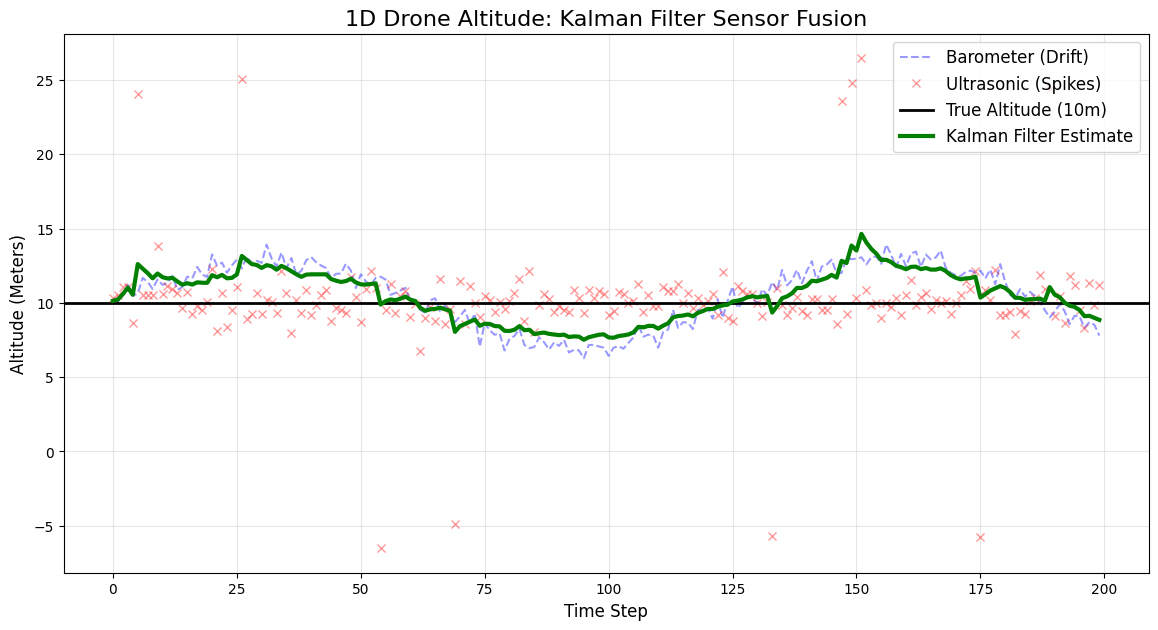

In [9]:
plt.figure(figsize=(14, 7))

# Plot the noisy sensors
plt.plot(barometer_data, label='Barometer (Drift)', color='blue', alpha=0.4, linestyle='--')
plt.plot(ultrasonic_data, label='Ultrasonic (Spikes)', color='red', alpha=0.4, marker='x', linestyle='None')

# Plot the Truth and the Kalman output
plt.axhline(true_altitude, color='black', label='True Altitude (10m)', linewidth=2)
plt.plot(kf_alt, label='Kalman Filter Estimate', color='green', linewidth=3)

plt.title('1D Drone Altitude: Kalman Filter Sensor Fusion', fontsize=16)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Altitude (Meters)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()